In [10]:
import numpy as np
import matplotlib.pyplot as plt

from setup3D import StartUp3D
from Maxwell3D import Maxwell3D
from mesh_reader3D import MeshReader3D

ids = np.array([0,1,2,3])
lcs = np.array([0.5,0.4,0.3,0.2])

erros = []
ks = []
for h in range(len(ids)):
    N = 2

    VX, VY, VZ, EToV = MeshReader3D(f'malhas3D/cavidade3D_h{h}.msh')

    malha = StartUp3D(N,EToV,VX,VY,VZ)

    Ez = np.sin(np.pi*malha.x)*np.sin(np.pi*malha.y)
    Hx = np.zeros((malha.Np,malha.K))
    Hy = np.zeros((malha.Np,malha.K))
    Hz = np.zeros((malha.Np,malha.K))
    Ex = np.zeros((malha.Np,malha.K))
    Ey = np.zeros((malha.Np,malha.K))

    FinalTime = 0.5
    Hx, Hy, Hz, Ex, Ey, Ez, t_final = Maxwell3D(Hx,Hy,Hz,Ex,Ey,Ez,FinalTime,malha,CFL=0.1,pml=False)

    Ez_analitico = np.sin(np.pi*malha.x)*np.sin(np.pi*malha.y)*np.cos(np.pi*np.sqrt(2)*t_final)

    M = np.linalg.inv(malha.V @ malha.V.T) 

    erro_nodal = Ez - Ez_analitico

    integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
    En = np.sqrt(integral_erro_sq)

    integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
    wt = np.sqrt(integral_analitico_sq)

    erro_L2_real = En / wt

    erros.append(erro_L2_real)
    ks.append(malha.K)



Número de vértices (VX): 141
Número de tetraedros (EToV): 376
Número de faces de contorno: 260
Tempo atual: 1.8440e-03 / 5.00e-01
Tempo atual: 3.6880e-03 / 5.00e-01
Tempo atual: 5.5321e-03 / 5.00e-01
Tempo atual: 7.3761e-03 / 5.00e-01
Tempo atual: 9.2201e-03 / 5.00e-01
Tempo atual: 1.1064e-02 / 5.00e-01
Tempo atual: 1.2908e-02 / 5.00e-01
Tempo atual: 1.4752e-02 / 5.00e-01
Tempo atual: 1.6596e-02 / 5.00e-01
Tempo atual: 1.8440e-02 / 5.00e-01
Tempo atual: 2.0284e-02 / 5.00e-01
Tempo atual: 2.2128e-02 / 5.00e-01
Tempo atual: 2.3972e-02 / 5.00e-01
Tempo atual: 2.5816e-02 / 5.00e-01
Tempo atual: 2.7660e-02 / 5.00e-01
Tempo atual: 2.9504e-02 / 5.00e-01
Tempo atual: 3.1348e-02 / 5.00e-01
Tempo atual: 3.3192e-02 / 5.00e-01
Tempo atual: 3.5036e-02 / 5.00e-01
Tempo atual: 3.6880e-02 / 5.00e-01
Tempo atual: 3.8725e-02 / 5.00e-01
Tempo atual: 4.0569e-02 / 5.00e-01
Tempo atual: 4.2413e-02 / 5.00e-01
Tempo atual: 4.4257e-02 / 5.00e-01
Tempo atual: 4.6101e-02 / 5.00e-01
Tempo atual: 4.7945e-02 / 5.0

Ordem de Convergência Espacial (k):
De lc = 0.5 para 0.4 -> Ordem = 2.78
De lc = 0.4 para 0.3 -> Ordem = 3.03
De lc = 0.3 para 0.2 -> Ordem = 3.30


Para h = 2.770984e-01 -> erro = 8.15e-02
Para h = 2.287904e-01 -> erro = 4.78e-02
Para h = 1.714993e-01 -> erro = 2.00e-02
Para h = 1.194574e-01 -> erro = 6.04e-03


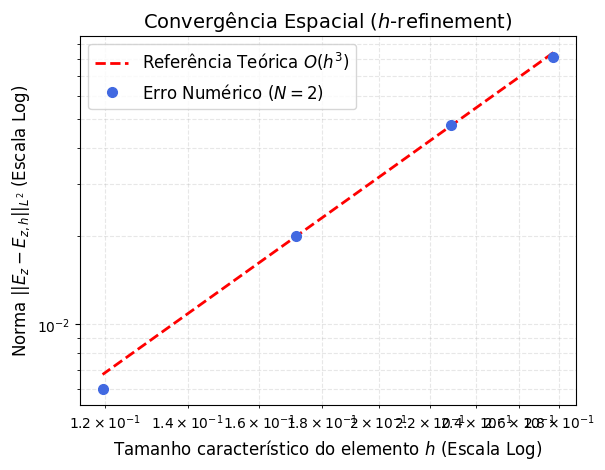

In [23]:
V_total = 8
ks = np.array(ks)
h_valores = (V_total/ks)**(1/3)

erros = np.array(erros) 

print("Ordem de Convergência Espacial (k):")
for i in range(len(h_valores) - 1):
    h_antigo = h_valores[i]
    h_novo = h_valores[i+1]
    
    E_antigo = erros[i]
    E_novo = erros[i+1]
    
    ordem_k = (np.log(E_novo) - np.log(E_antigo)) / (np.log(h_novo) - np.log(h_antigo))
    
    print(f"De lc = {lcs[i]} para {lcs[i+1]} -> Ordem = {ordem_k:.2f}")

print('\n')

for j in range(len(h_valores)):
    print(f'Para h = {h_valores[j]:2e} -> erro = {erros[j]:.2e}')

ordem_teorica = N + 1

# Cria os pontos para a linha de referência (usando os dois últimos pontos de h para alinhar visualmente)
h_ref = np.array([h_valores[0], h_valores[-1]])

# Ancoramos a linha de referência no penúltimo ponto de erro e aplicamos a inclinação teórica
erro_ref = erros[-2] * (h_ref / h_valores[-2])**ordem_teorica

plt.figure()

plt.loglog(h_ref, erro_ref, ls='--', linewidth=2, label=f'Referência Teórica $O(h^{ordem_teorica})$',color='red')

plt.loglog(h_valores, erros,'o', color='royalblue',markersize='7', label=r'Erro Numérico ($N=2$)')
plt.xlabel(r"Tamanho característico do elemento $h$ (Escala Log)", fontsize=12)
plt.ylabel(r"Norma $||E_z - E_{z,h}||_{L^2}$ (Escala Log)", fontsize=12)
plt.title(r"Convergência Espacial ($h$-refinement)", fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=12)
plt.show()